# Expressing Attention with Weights and a Residual Connection

This notebook writes causal self-attention with its query, key, value and output projections and a residual connection around it, and draws it as a neural circuit diagram. It then derives the training step, whose backward pass returns the gradient of the state and the gradient of each of the four weights. The last cell writes a page that switches between the model and its training step.

*Written by Claude Opus 5.5 (1M context) at reasoning effort 40, 2026-09-27.*

In [1]:
import dataclasses

import advanced_axis_dynamics.algebra.slide_causal_reads_backwards as slide_causal_reads_backwards
import notebooks.website.tutorial.derive_training_step as derive_training_step
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.website.tutorial.express_attention as express_attention
import notebooks.website.tutorial.tutorial_pages as tutorial_pages
import notebooks.website.website_output as website_output

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE,
    dark_mode=notebook_diagrams.ColorMode.LIGHT,
    advanced_display=notebook_diagrams.AdvancedDisplay.LEGEND,
    operator_explanations=express_attention.OPERATOR_EXPLANATIONS,
    operator_references=express_attention.OPERATOR_REFERENCES,
    operator_roles=express_attention.SINGLE_HEAD_ROLES,
    reindexing_explanations=express_attention.REINDEXING_EXPLANATIONS,
    title='Attention with Weights and a Residual Connection')
PAGE = dataclasses.replace(
    DIAGRAMS, mode=notebook_diagrams.DiagramMode.HTML,
    advanced_display=notebook_diagrams.AdvancedDisplay.INTERACTIVE,
    page_directory=website_output.TUTORIAL_PAGES)

MODEL = express_attention.attention_with_weights_and_residual()
DISPLAYED = slide_causal_reads_backwards.slide_causal_reads_backwards(MODEL)
TRAINING_STEP = derive_training_step.derive_training_step(MODEL)

## Projecting one state into queries, keys and values

The model reads a state of $|m|$ channels for each token of the axis $x$. Three learned matrices, $W^{Q}$, $W^{K}$ and $W^{V}$, project the state of each token into a query, a key and a value of $|d|$ channels, and the scaled dot-product attention of [Expressing Attention](Attention.ipynb) combines them. $W^{O}$ projects the result for each token back to $|m|$ channels. The residual connection adds that result to the state, so the model computes $z + \mathrm{Attention}(z)$ for the state $z$ and returns an array of the shape it reads. Each learned matrix is drawn as a box named after it. The wires of the state split where the state is copied into the projections and into the residual connection, and the plus sign is the addition.

## Reading the earlier tokens through a causal mask

Each token attends to itself and to the tokens before it. The keys and the values are read through the view named Mask, drawn as a pentagon, which holds token $i_{x} - i_{w}$ at slot $i_{w}$ of token $i_{x}$. Slot $0$ holds the token itself and slot $1$ the token before it, and the slot axis $w$ has as many positions as there are tokens. A slot before the first token names a negative position. The expression gives every position outside an axis the same value, the universal unit, which the softmax and the weighted sum skip, so each token attends to the slots that hold a token and to no others. The view marks the slot axis as $w|x$, which reads as the slots of $w$ that hold a value for a given token of $x$. Those are the slots with $i_{w} \le i_{x}$. No operator multiplies the scores by a mask, and no score is set to $-\infty$.

An implementation applies the mask to the keys and the values after their projections, and the model is built that way. The figure draws the model with the mask moved back to the copy of the state, a form named the CausalSlide. A projection computes the same function at every token, so projecting the state of token $i_{x} - i_{w}$ gives the key the mask would have read at slot $i_{w}$. In the CausalSlide the mask reads the state once, and $W^{K}$ and $W^{V}$ run over the tokens and the slots. The two forms compute the same result.

Causal self-attention with a residual connection, in the CausalSlide form. The mask reads the state at the copy that feeds the queries, and W^K and W^V run over the tokens and the slots.


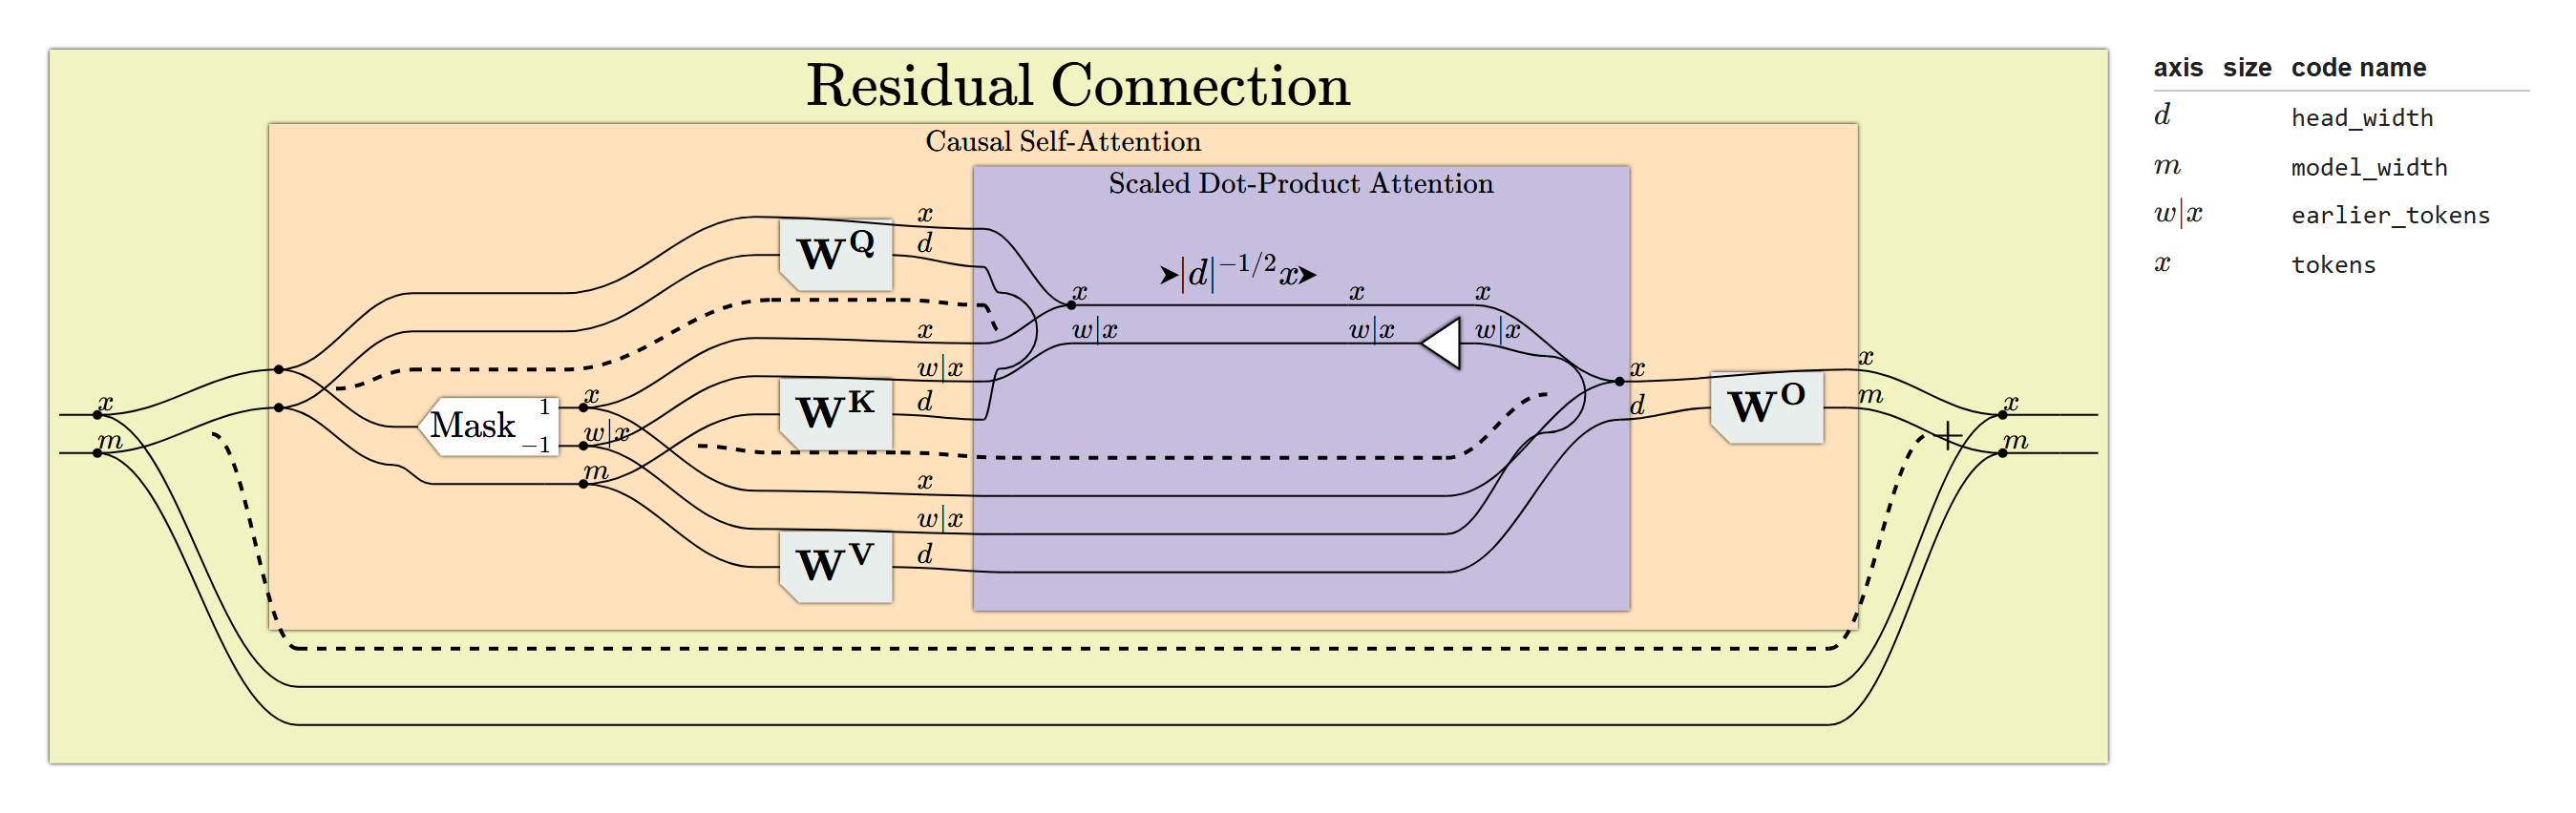

In [2]:
await notebook_diagrams.show_diagram(
    DISPLAYED,
    'Causal self-attention with a residual connection, in the CausalSlide form. The '
    'mask reads the state at the copy that feeds the queries, and W^K and W^V run '
    'over the tokens and the slots.',
    width=1400, settings=DIAGRAMS)

## Reading the weights from the tape

A linear map holds its matrix inside the operator, and the model names each matrix only as the label of its box. The derivation needs the matrices as values, so it first writes every matrix as a read from a slot of a tape named after the matrix. A read from the tape is called a grab. Each grab is drawn on the box it feeds, as an arrow arriving from above with the name of its slot. A matrix is shared by every token, so each grab reads one array of $|m| |d|$ entries, and the model keeps the domain and the codomain it had. The derivation starts from the model as built, with the mask after $W^{K}$ and $W^{V}$, for the reason the next section gives, so the figure draws that form.

The model with each of its four matrices grabbed from a slot named after it.


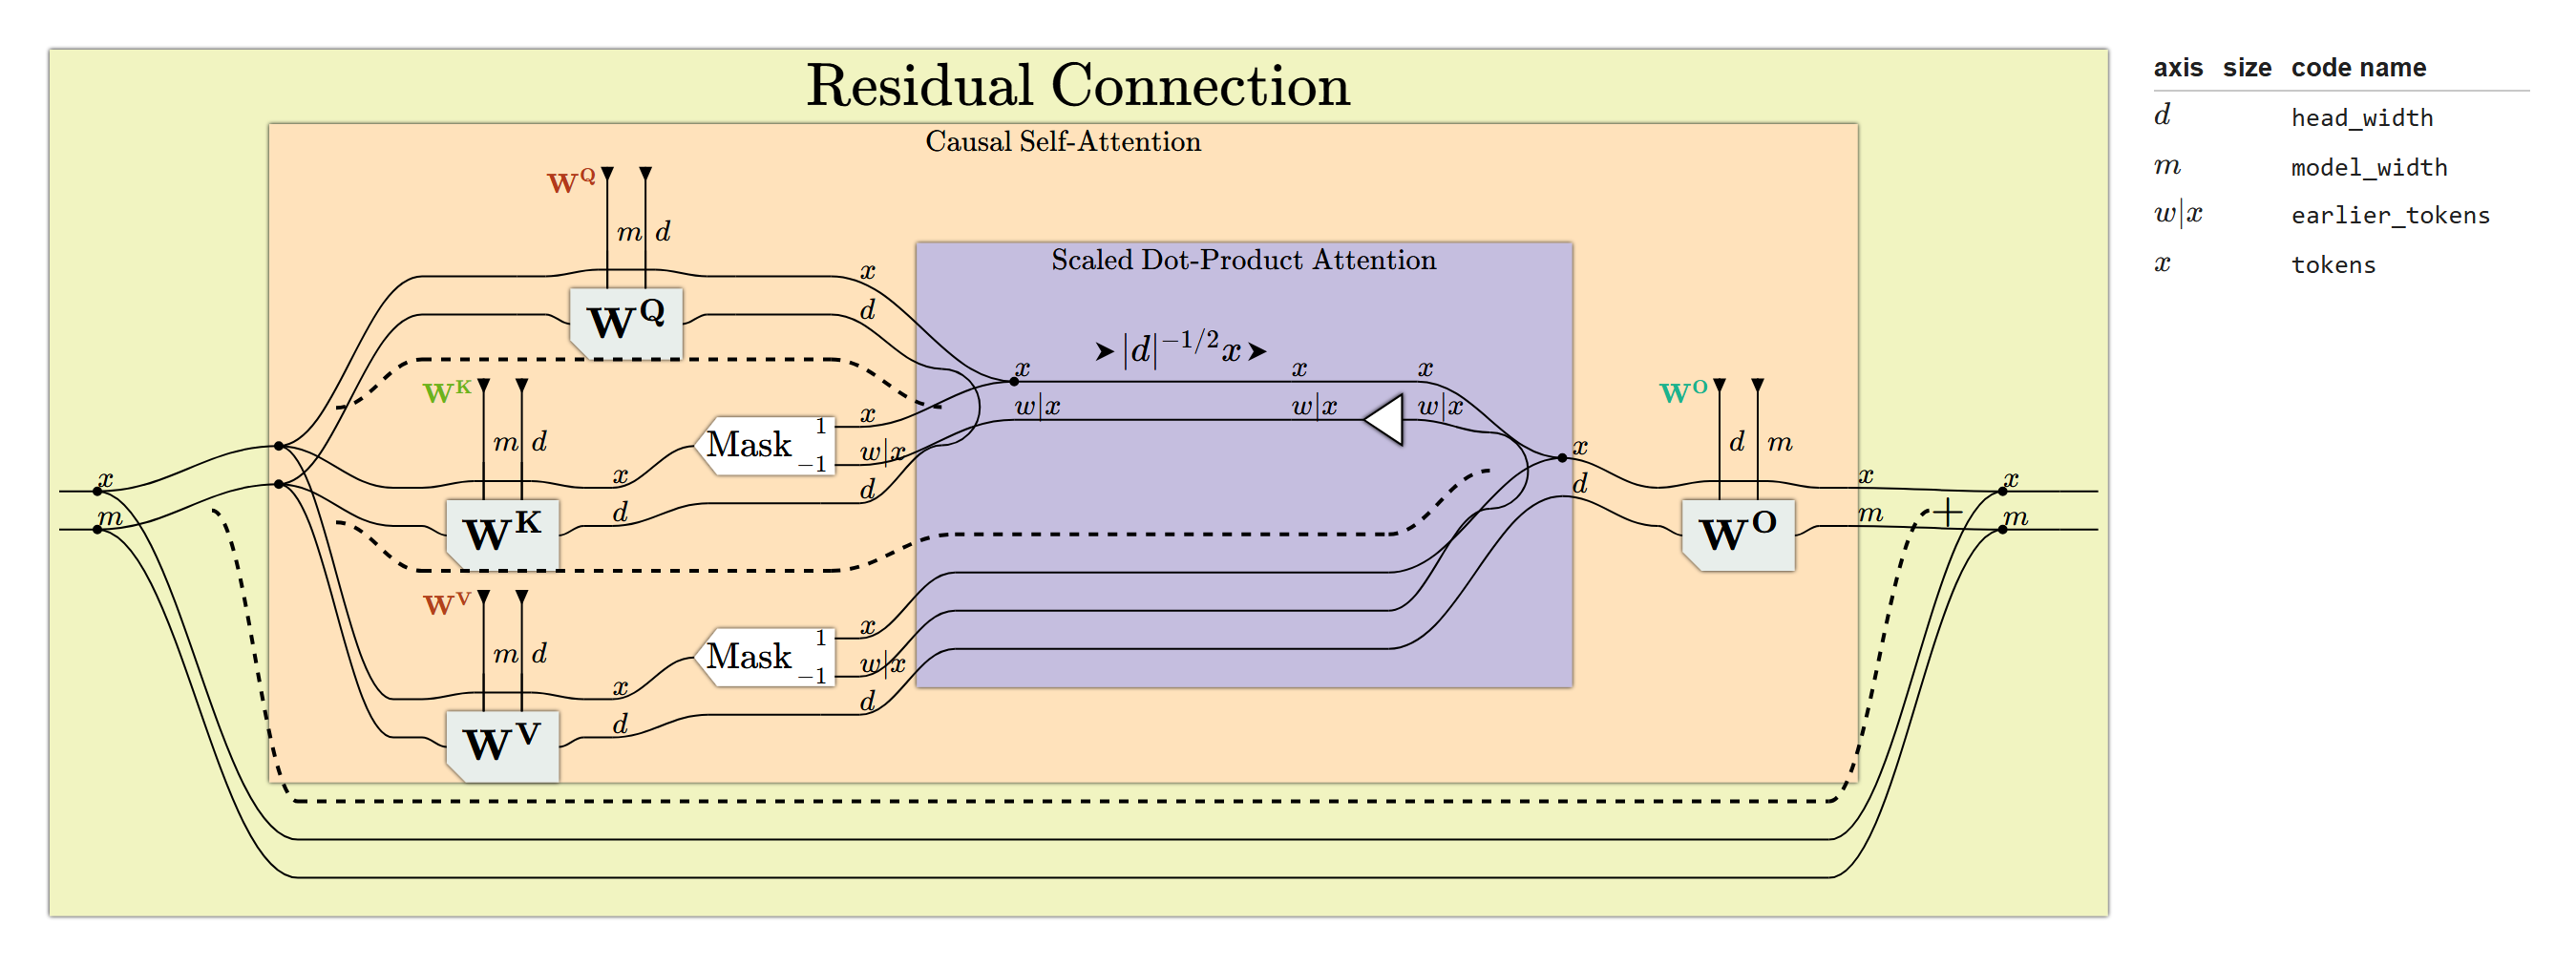

In [3]:
await notebook_diagrams.show_diagram(
    TRAINING_STEP.parametrised,
    'The model with each of its four matrices grabbed from a slot named after it.',
    width=1500, settings=DIAGRAMS)

## Deriving the training step

The training step is derived from the model as built, with the mask after the projections. An implementation computes the key and the value of each token once and reads them through the mask, and the training step does the same. In the CausalSlide $W^{K}$ and $W^{V}$ run over every slot of every token, and a training step derived from it saves the keys and the values at $[x, w|x, d]$.

The backward pass reads $\mathrm{d}z'$, the gradient of the loss with respect to the output of the model, and returns $\mathrm{d}z$, the gradient with respect to the state. It writes the gradients $\mathrm{d}W^{Q}$, $\mathrm{d}W^{K}$, $\mathrm{d}W^{V}$ and $\mathrm{d}W^{O}$ to slots of their own, and it grabs each matrix from the slot the forward pass read it from. The softmax is written out and its division moved past the weighted sum, and the backward pass rebuilds the exponentials of the scores from the saved queries and keys, as in [Expressing Attention](Attention.ipynb). The keys and the values are saved as the projections return them, at $[x, d]$, and the backward pass reads them through the mask where it needs them. The forward pass saves six arrays to the tape, which are the state at $[x, m]$, the queries, the keys and the values at $[x, d]$, the reciprocals of the row sums at $[x]$ and the result of the attention before $W^{O}$ at $[x, d]$. The gradients of $W^{Q}$, $W^{K}$ and $W^{V}$ read the saved state.

The residual connection reverses into an addition. The gradient of the output reaches the state directly, and the gradient that passes back through the attention is added to it. The mask reverses into its transpose, which adds the gradient at slot $i_{w}$ of token $i_{x}$ into token $i_{x} - i_{w}$ and drops a slot that holds no token. The gradient of the keys and the gradient of the values each pass through a transpose of the mask, from $[x, w|x, d]$ to $[x, d]$. The gradients through $W^{Q}$, $W^{K}$ and $W^{V}$ are added into one gradient of the state at $[x, m]$, and the gradient of every matrix sums over the tokens.

Every block of the model is kept. The forward pass holds the three blocks the model was written with, and the backward pass holds one block for each, titled $R[\ldots]$. The softmax is one operator and has no block of its own, so its written-out form stands inside the scaled dot-product attention. Both passes compile to PyTorch, and on random inputs the backward pass returns the gradients that `torch.autograd` computes for causal self-attention with a residual connection written directly in PyTorch, for the state and for each of the four matrices.

The training step. The backward pass returns the gradient of the state and writes the gradients of the four matrices to the tape.


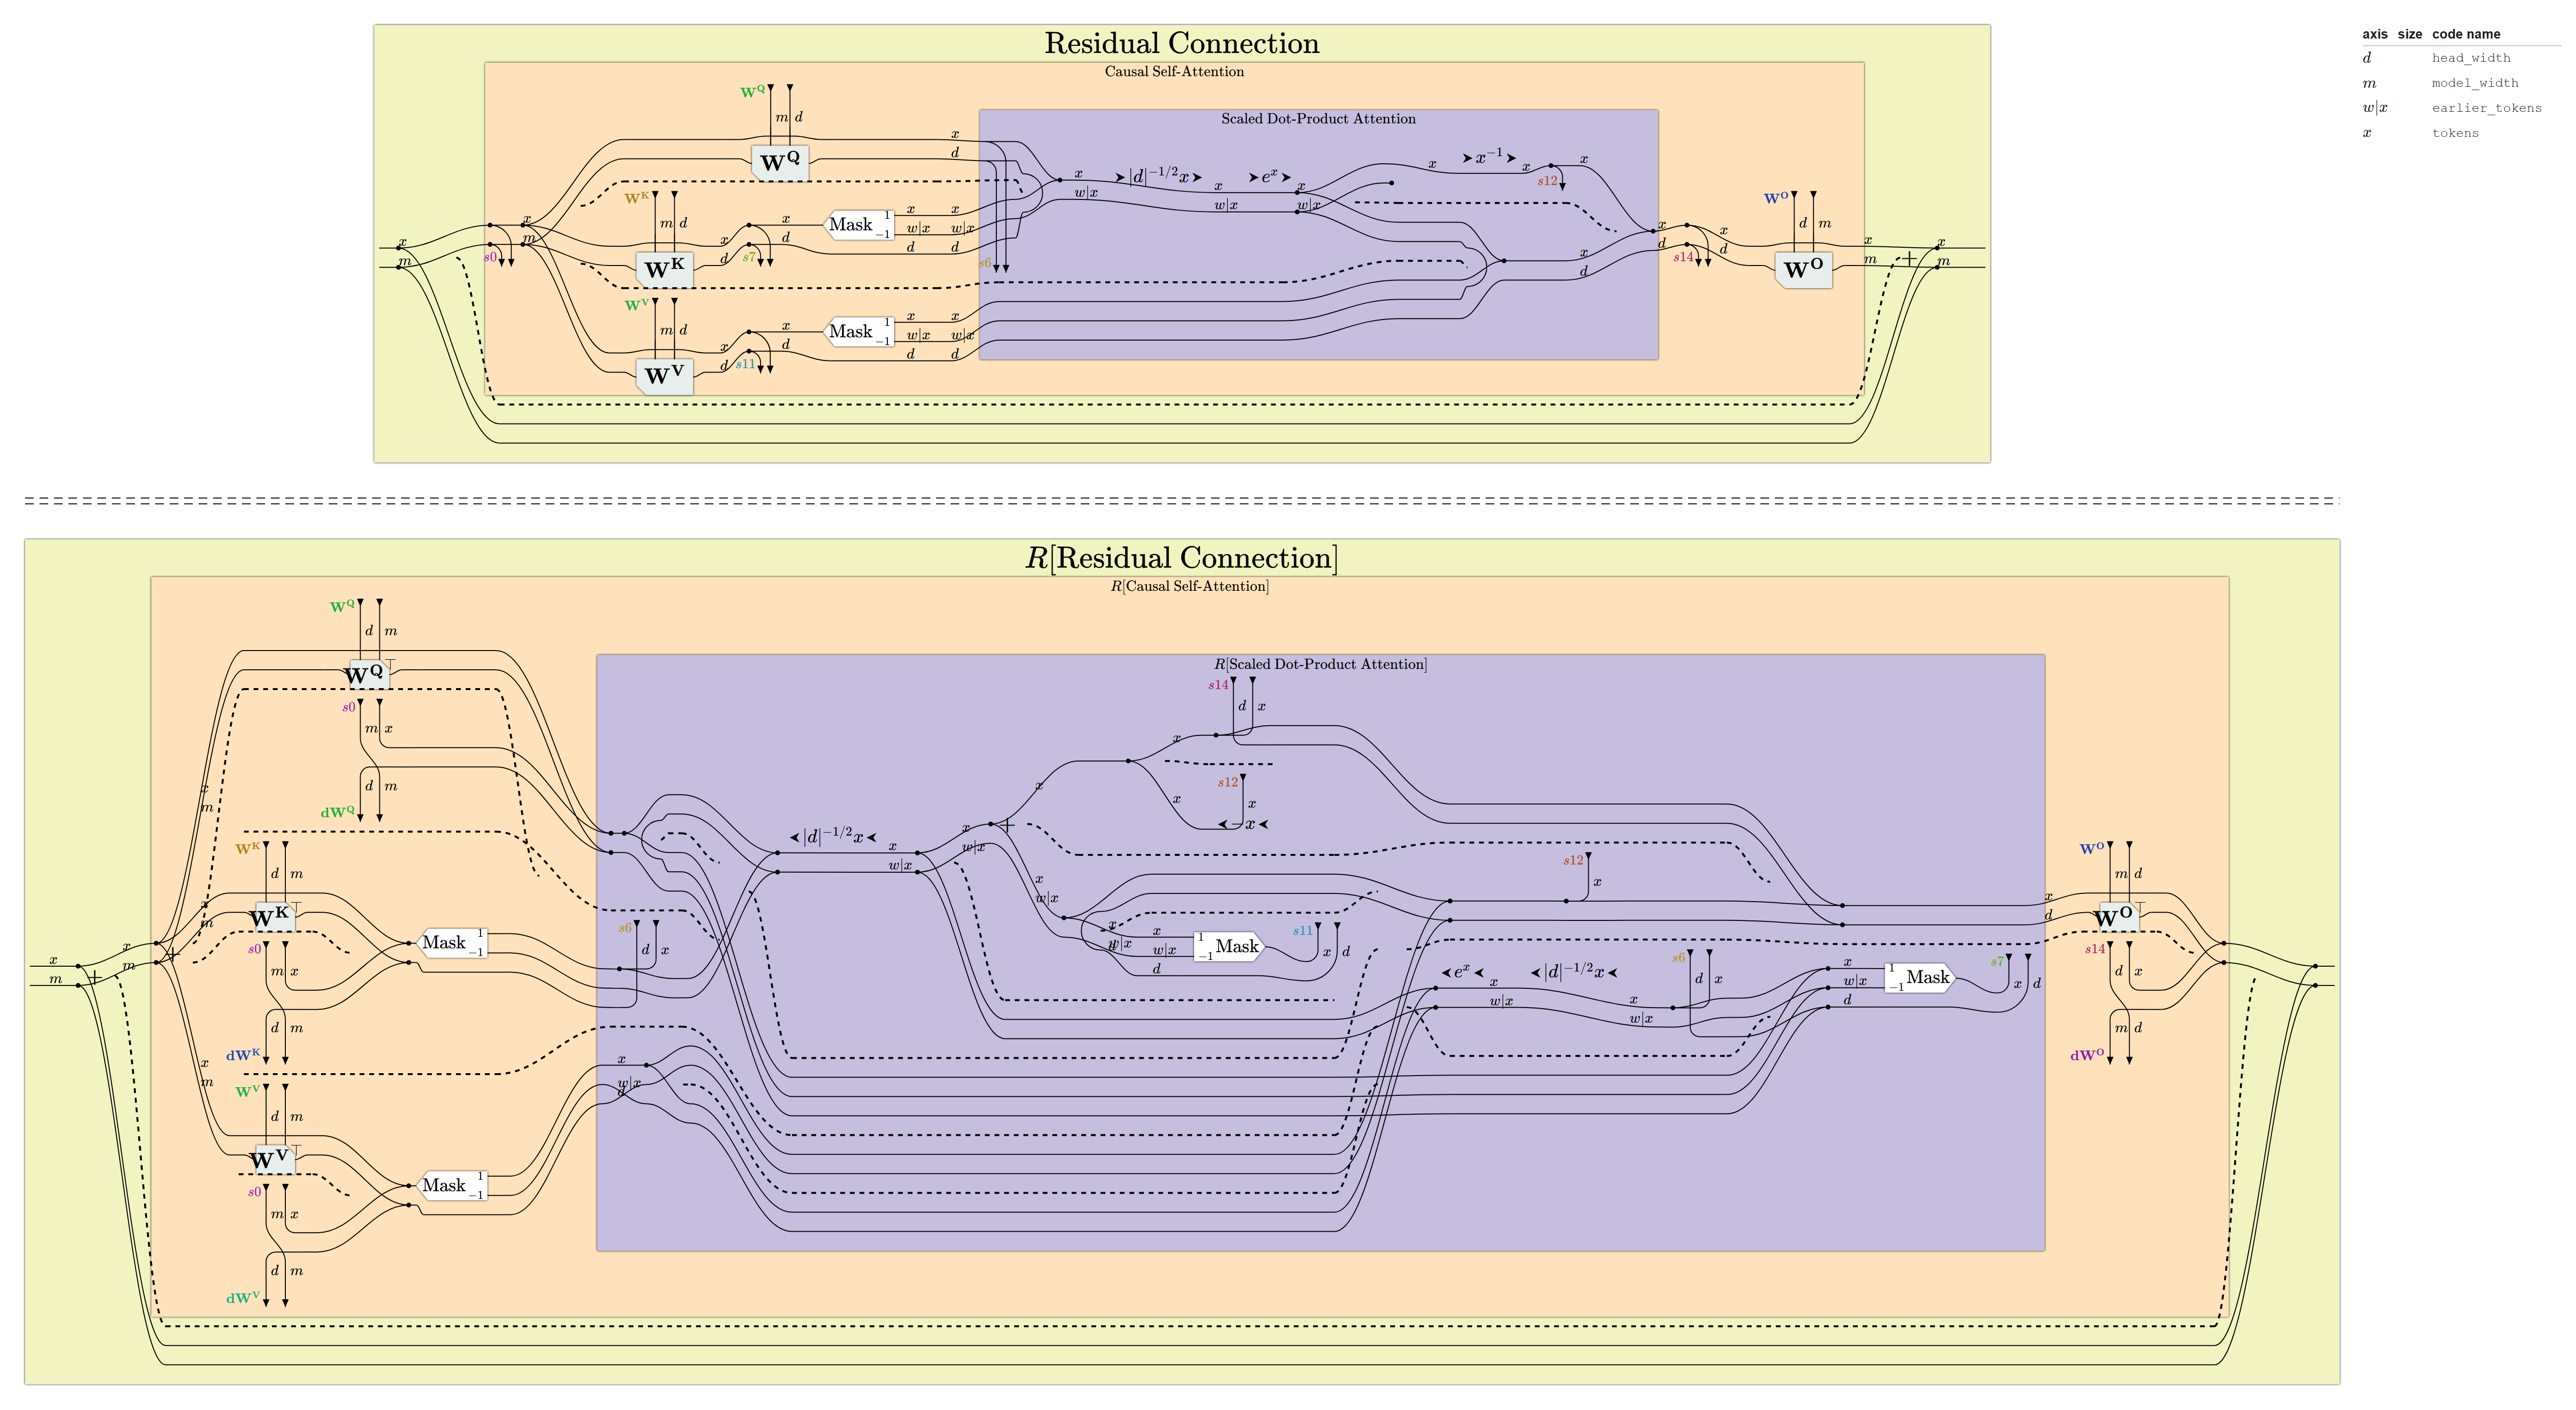

In [4]:
await notebook_diagrams.show_diagram(
    TRAINING_STEP.forward_over_backward(),
    'The training step. The backward pass returns the gradient of the state and '
    'writes the gradients of the four matrices to the tape.',
    width=2600, settings=DIAGRAMS)

## The interactive page

The last cell writes the model and its training step to `notebooks/website/output/tutorial/AttentionWithWeightsAndResidual/index.html`, one file that opens with no server and no network. The selector on the page switches between the forward pass and the training step. Resting the pointer on a block opens a box with its title and its description, resting it on a matrix opens the role of that matrix, and resting it on the mask opens the formula of the view.

In [5]:
await notebook_diagrams.show_page_variants(
    tutorial_pages.attention_with_weights_and_residual_page(
        DISPLAYED, TRAINING_STEP, PAGE),
    'Causal self-attention with a residual connection and its training step as one '
    'HTML file.',
    settings=PAGE, slug=tutorial_pages.ATTENTION_WITH_WEIGHTS_AND_RESIDUAL_SLUG,
    initial=tutorial_pages.FORWARD)

Causal self-attention with a residual connection and its training step as one HTML file.


(written to notebooks/website/output/tutorial/AttentionWithWeightsAndResidual/)
